# Smoothing Noisy Sensor Data

Sensors are never perfect. Even a good altimeter on a model rocket will report numbers that fluctuate around the *true* altitude. That fluctuation is called **noise**.

A **filter** is a small piece of math that takes a noisy signal and tries to recover a smoother estimate of the ground truth signal (the true altitude in our example). In this notebook we look at two simple filters:

1. **SMA**: Simple Moving Average
2. **EMA**: Exponential Moving Average

For each one we'll see the formula, the code, and what it does to a noisy rocket altitude signal. 
There's also a bonus section at the end on *Kalman Filters* if you are interested, but feel free to skip it.

### All our filters are *causal*

A **causal** filter only uses the current sample and past samples, never future ones. That sounds obvious, but it has a real consequence.

Picture what's happening on a flying rocket. At time $t$ you've just gotten a fresh altimeter reading, and you want a smoothed estimate of the altitude *right now* so the flight computer can decide things like when to deploy the parachute. The next sample literally hasn't been measured yet. It lives in the future. So your filter has no choice: it can only work with what it's already seen.

Any filter that runs live (a rocket, a drone, anything streaming) has to be causal. There is no other option unless you find a way to predict the future!

The price you pay is **lag**. When the signal changes sharply, like at the rocket's apogee, a causal filter always reacts a little late, because the only evidence it has is from *before* the turn. The more you smooth, the more it lags.

*(If you're processing data after the fact, f.ex replaying recorded flight data, you can do better. A **non-causal** filter is allowed to peek at "future" samples because they have already been recorded.)*

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, FloatSlider, IntSlider, FloatLogSlider, Checkbox

%matplotlib inline

## Our test signal

Our test signal is a coarsely simulated altitude trace from a small model rocket launch. It roughly resembles a short powered boost followed by a ballistic coast up and back down, giving a parabolic trajectory.

To fake an imperfect altimeter, we add artificial Gaussian noise to the signal and use the noisy version as input to the filters.

In [ ]:
from rocket_signal import generate

t, true_sig = generate()
dt = t[1] - t[0]

# Add Gaussian noise to fake an imperfect altimeter (σ = 2 m).
noisy_demo = true_sig + 2.0 * np.random.default_rng(0).standard_normal(t.size)

## 1. Simple Moving Average (SMA)

The simplest idea: **average the last $N$ samples**.

$$
y_n \;=\; \frac{1}{N}\bigl(x_n + x_{n-1} + x_{n-2} + \dots + x_{n-N+1}\bigr)
$$

- A bigger window $N$ → smoother output, but **slower** to react to changes.
- A small window → reacts fast but stays noisy.
- The filter has to remember the last $N$ samples, so it costs memory.

In [ ]:
def sma(x, window):
    padded = np.concatenate([np.full(window-1, x[0]), x])
    return np.convolve(padded, np.ones(window)/window, mode='valid')

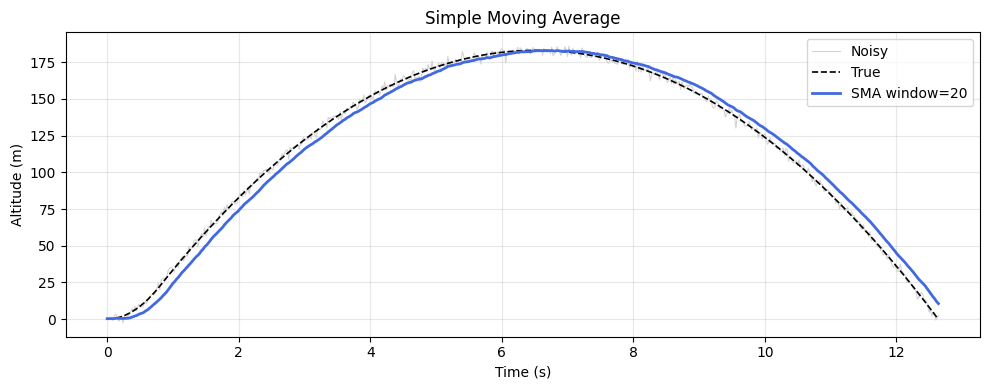

In [14]:
# What does it look like? Window of 20 samples on the noisy rocket signal.
plt.figure(figsize=(10, 4))
plt.plot(t, noisy_demo, color='lightgray', lw=0.8, label='Noisy')
plt.plot(t, true_sig, 'k--', lw=1.2, label='True')
plt.plot(t, sma(noisy_demo, 20), color='royalblue', lw=2, label='SMA window=20')
plt.xlabel('Time (s)'); plt.ylabel('Altitude (m)')
plt.title('Simple Moving Average')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## 2. Exponential Moving Average (EMA)

This is the classic **recursive first-order filter**. Instead of remembering many samples, it only remembers its *previous output*:

$$
y_n \;=\; \alpha\, x_n \;+\; (1 - \alpha)\, y_{n-1}
$$

where $0 < \alpha \le 1$ is the **smoothing factor**.

- $\alpha$ close to $1$ → trust the new measurement, react fast, less smoothing.
- $\alpha$ close to $0$ → trust the old estimate, react slowly, lots of smoothing.

Why is it called *recursive*? Because the new output $y_n$ is defined using the *previous output* $y_{n-1}$ — the formula refers to itself. That's also why it only needs to store one number, no matter how long the signal is.

In [15]:
def ema(x, alpha):
    y = np.empty_like(x)
    y[0] = x[0]
    for i in range(1, len(x)):
        y[i] = alpha*x[i] + (1-alpha)*y[i-1]
    return y

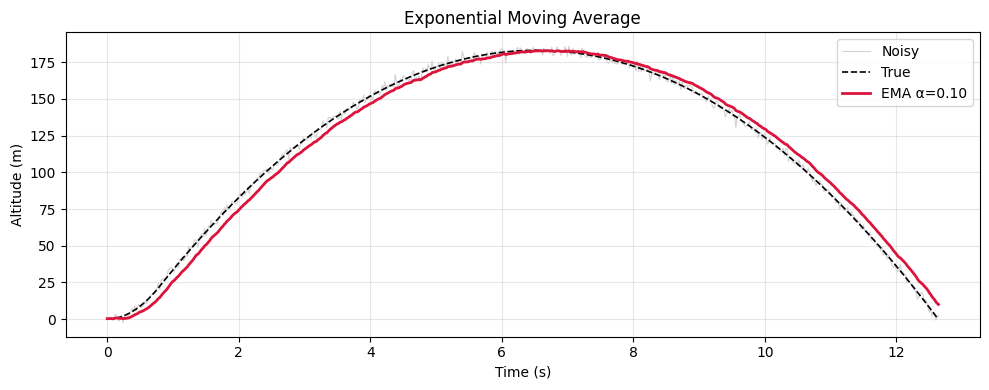

In [16]:
# What does it look like? alpha = 0.10 on the same noisy signal.
plt.figure(figsize=(10, 4))
plt.plot(t, noisy_demo, color='lightgray', lw=0.8, label='Noisy')
plt.plot(t, true_sig, 'k--', lw=1.2, label='True')
plt.plot(t, ema(noisy_demo, 0.10), color='crimson', lw=2, label='EMA α=0.10')
plt.xlabel('Time (s)'); plt.ylabel('Altitude (m)')
plt.title('Exponential Moving Average')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Try it yourself

Move the sliders and watch the two filters react in real time:

- **Noise σ** — how noisy the simulated altimeter is.
- **EMA α** — small = smooth & laggy, large = fast & noisy.
- **SMA window** — number of samples averaged.

Things to look for:
- Which filter follows the sharp turn at the apex best?
- Which one *lags* most when the rocket is accelerating? (Remember: both are causal — they only see the past.)
- What happens to each filter when you crank the noise way up?

In [ ]:
@interact(
    noise=FloatSlider(min=0.0, max=10.0, step=0.1, value=2.0,
                      description='Noise σ (m)', continuous_update=False),
    show_sma=Checkbox(value=True,  description='Show SMA'),
    window=IntSlider(min=1, max=100, step=1, value=20,
                     description='SMA window', continuous_update=False),
    show_ema=Checkbox(value=True,  description='Show EMA'),
    alpha=FloatSlider(min=0.01, max=1.0, step=0.01, value=0.10,
                     description='EMA α', continuous_update=False),
)
def plot_sma_ema(noise, show_sma, window, show_ema, alpha):
    # Fixed seed → noise pattern stays the same as you move the slider, only its magnitude changes.
    noisy = true_sig + noise * np.random.default_rng(0).standard_normal(t.size)
    plt.figure(figsize=(11, 5))
    plt.plot(t, noisy,    color='lightgray', lw=0.8, label='Noisy')
    plt.plot(t, true_sig, 'k--', lw=1.2, label='True')
    if show_sma:
        plt.plot(t, sma(noisy, window), color='royalblue', lw=2, label=f'SMA window={window}')
    if show_ema:
        plt.plot(t, ema(noisy, alpha),  color='crimson',   lw=2, label=f'EMA α={alpha:.2f}')
    plt.xlabel('Time (s)'); plt.ylabel('Altitude (m)')
    plt.title(f'SMA vs EMA  (σ = {noise:.1f} m)')
    plt.legend(loc='upper right'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

---

## Bonus: the Kalman filter

This is a peek at what more advanced filtering looks like — closer to what we actually use at ARIS. Feel free to skip if it gets too dense!

The two filters above know nothing about the rocket or how it moves. They just smooth numbers.

A **Kalman filter** is smarter: it uses a *model* of how the system changes.

### The intuition

Imagine a car cruising down the highway at 50 m/s, and we're building a filter to smooth the velocity readings.

SMA and EMA only look at past samples and average them — so the more they smooth, the more they lag. The trick to killing that lag is to **predict** where the signal is going next.

For our car, it's very likely we'll still be at ~50 m/s a moment from now. Slamming to 0 m/s in a single sample is basically impossible — cars just don't decelerate that fast. A Kalman filter uses that knowledge: at every step it combines

1. a **prediction** from the model ("probably still around 50 m/s"), and
2. the **new noisy measurement**,

weighted by how much it trusts each. The result is a smoother estimate *with much less lag* than a plain moving average — and a better guess at the true underlying signal (the actual speed of the car).

### Our model: constant velocity

We track two things at every moment: altitude $h$ and vertical velocity $v$.

$$
\mathbf{x} = \begin{bmatrix} h \\ v \end{bmatrix}
$$

Between two samples (a time step $\Delta t$ apart) we *predict* the next state assuming velocity stays constant:

$$
h_{n+1} = h_n + v_n \, \Delta t \qquad v_{n+1} = v_n
$$

In matrix form:

$$
\mathbf{x}_{n+1} \;=\; F\, \mathbf{x}_n, \qquad F = \begin{bmatrix} 1 & \Delta t \\ 0 & 1 \end{bmatrix}
$$

Of course velocity is *not* really constant (gravity, motor thrust...), so we tell the filter how much we trust this assumption with a parameter $q$ (process noise). And we tell it how noisy the sensor is with $r$ (measurement noise).

Each step the filter does two things:
1. **Predict** the next state using the model.
2. **Correct** the prediction using the new measurement, weighted by how much it trusts each.

Tuning $q$ is the main knob: small $q$ → strongly trust the model (smooth, may lag); large $q$ → strongly trust the measurements (responsive, noisier).

In [18]:
def kalman(x, dt, q, r):
    F = np.array([[1, dt], [0, 1]])           # constant-velocity transition
    H = np.array([[1, 0]])                    # we only measure altitude
    Q = np.array([[dt**4/4, dt**3/2],
                  [dt**3/2, dt**2]]) * q      # process noise covariance
    R = np.array([[r]])                       # measurement noise covariance
    I = np.eye(2)

    state = np.array([x[0], 0.0])
    P = np.eye(2)
    out = np.empty_like(x)
    for i in range(len(x)):
        # Predict
        state = F @ state
        P = F @ P @ F.T + Q
        # Correct using the new measurement
        y_innov = x[i] - (H @ state)[0]
        S = (H @ P @ H.T + R)[0, 0]
        K = (P @ H.T).flatten() / S
        state = state + K * y_innov
        P = (I - np.outer(K, H)) @ P
        out[i] = state[0]
    return out

## Compare all three side by side

In [ ]:
@interact(
    noise=FloatSlider(min=0.0, max=10.0, step=0.1, value=2.0,
                      description='Noise σ (m)', continuous_update=False),
    show_sma=Checkbox(value=True,  description='Show SMA'),
    window=IntSlider(min=1, max=100, step=1, value=20,
                     description='SMA window', continuous_update=False),
    show_ema=Checkbox(value=True,  description='Show EMA'),
    alpha=FloatSlider(min=0.01, max=1.0, step=0.01, value=0.10,
                     description='EMA α', continuous_update=False),
    show_kalman=Checkbox(value=True,  description='Show Kalman'),
    q=FloatLogSlider(value=0.5, base=10, min=-5, max=5, step=0.1,
                     description='Kalman q', continuous_update=False),
)
def plot_all(noise, show_sma, window, show_ema, alpha, show_kalman, q):
    noisy = true_sig + noise * np.random.default_rng(0).standard_normal(t.size)
    r = max(noise, 0.01) ** 2
    plt.figure(figsize=(11, 5))
    plt.plot(t, noisy,    color='lightgray', lw=0.8, label='Noisy')
    plt.plot(t, true_sig, 'k--', lw=1.2, label='True')
    if show_sma:
        plt.plot(t, sma(noisy, window),       color='royalblue', lw=2, label=f'SMA window={window}')
    if show_ema:
        plt.plot(t, ema(noisy, alpha),        color='crimson',   lw=2, label=f'EMA α={alpha:.2f}')
    if show_kalman:
        plt.plot(t, kalman(noisy, dt, q, r),  color='seagreen',  lw=2, label=f'Kalman q={q:.3g}')
    plt.xlabel('Time (s)'); plt.ylabel('Altitude (m)')
    plt.title(f'SMA vs EMA vs Kalman  (σ = {noise:.1f} m)')
    plt.legend(loc='upper right'); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()